In [2]:
from IPython.display import HTML

# Observable
obs = [
   "#4269D0FF", "#F0BD3CFF", "#FF5D45FF", "#6CC5B0FF", "#3CA951FF", "#FF8AB7FF",
   "#A463F2FF", "#97BBF5FF", "#9C6B4EFF", "#9498A0FF", "#1B1B1BFF"
]

html = "".join(
    f'<div style="display:inline-block;width:100px;height:30px;background:{c};margin:2px">{c}</div>'
    for c in obs
)

HTML(html)

## Template

In [20]:
import numpy as np
import pandas as pd
from urllib.parse import urlparse, parse_qs

INPUT_CSV = "../data/albums.csv"
OUTPUT_QMD = "albums.qmd"

df = pd.read_csv(INPUT_CSV)
df = df.sort_index(ascending=False)

top_n = 100

print_lyric = False
print_mood_scores = False
print_tags = False

max_mood_score = 5
mood_colors = {"Sad": "bg-primary",
                "Happy": "bg-success",
                "Angry": "bg-danger",
                "Dark": "bg-dark",
                "Dreamy": "bg-warning"
                }
mood_colors = {"Sad": obs[0],
                "Happy": obs[3],
                "Angry": obs[2],
                "Dark": obs[-1],
                "Dreamy": obs[1],
                "Passion": obs[6],
                "Groovy": obs[8]
                }


def flag_emoji(code):
    return ''.join(chr(127397 + ord(c)) for c in code.upper())

content = "<div class=\"songs\">" # inside this is sortable

for i in df.tail(top_n).index:
    row = df.loc[i]
    ranking = i + 1
    artist = row["Artist"]
    cover = row["CoverFile"]
    if pd.isna(cover):
        continue
    title = row["Title"]
    year = int(row["Year"])
    genre = row["Genre"]
    lyric = row["Lyric"]
    tags = row["Tags"]
    country = row["Country"]
    country_name = row["CountryName"]
    notes = row["Notes"]
    song = row["FavSong"]
    url = row["URL"]

    if pd.isna(tags):
        tags = []
    else:
        tags = tags.split(",")
    #tags += [flag_emoji(country) + " " + country] if pd.notna(country) else []

    sad, happy, angry, groovy, dark, dreamy, passion = 0, 0, 0, 0, 0, 0, 0
    if print_mood_scores:
        for col in df.columns:
            if col.startswith("Mood_") and row[col] >= max_mood_score:
                hasMaxAttribute = "True"
            if col.endswith("Sad"):
                sad = int(row[col])
            elif col.endswith("Happy"):
                happy = int(row[col])
            elif col.endswith("Angry"):
                angry = int(row[col])
            elif col.endswith("Groovy"):
                groovy = int(row[col])
            elif col.endswith("Dark"):
                dark = int(row[col])
            elif col.endswith("Dreamy"):
                dreamy = int(row[col])
            elif col.endswith("Passion"):
                passion = int(row[col])

    # note these unclipped raw scores can exceed max_mood_score fo sorting purposes
    song_classes = f'{{.album data-passion="{passion}" data-dreamy="{dreamy}" data-dark="{dark}" data-groovy="{groovy}" data-angry="{angry}" data-happy="{happy}" data-sad="{sad}" data-rank="{ranking}" data-year="{year}"}}'

    content += f"## {ranking}. {artist} - {title}{song_classes}\n"
    content += f"""<div class="album-container"><div class="album-image">![](../img/{cover})</div><div class="album-info">"""
    content += f"""<p class="mb-0"><strong>Year:</strong> {year}<br>"""
    content += f"<strong>Country:</strong> {flag_emoji(country)} {country_name}<br>"
    content += f"<strong>Genres:</strong> {genre}<br>"
    content += f"""<strong>Favorite Song: <a href="{url}" target="_blank" rel="noopener noreferrer">{song}</a></strong></p>"""
    content += "</div></div>"

    if print_tags:
        tag_string = """<div class="toggle-tags"><div class="d-flex gap-2 mb-2 mt-2">"""
        for tag in tags:
            tag_string += f"""<span class="badge bg-primary rounded-pill">{tag.strip()}</span>"""
        tag_string += "</div></div>"
        content += tag_string
    content += "\n"

    if pd.notna(lyric) and print_lyric:
        content += f"""<span style="color:#769FCD"><i>{lyric.replace(' / ', '\\\n')}</i></span><br><br>"""

    if print_mood_scores:
        score_string = "<div class='toggle-mood'>"
        for col in df.columns:
            if col.startswith("Mood_"):
                mood = col.split("_")[1]
                score = int(df.loc[i, col])  # 0–5
                if score > 0:
                    score = np.clip(score, 0, max_mood_score)
                    percent = score / 5 * 100
                    # progress bar won't display if not on one line
                    #score_string += f"""<div style="display:grid; grid-template-columns: 64px 160px; align-items:center; margin-bottom:0px;"><div>{mood}</div><div class="progress" style="height:14px;"><div class="progress-bar {mood_colors[mood]}" role="progressbar" style="width:{percent}%;"></div></div></div>"""
                    score_string += f"""<div style="display:grid; grid-template-columns: 70px 160px; align-items:center; margin-bottom:0px;"><div>{mood}</div><div class="progress" style="height:14px;"><div class="progress-bar" style="background-color: {mood_colors[mood]}; width:{percent}%;" role="progressbar"></div></div></div>"""
                    #score_string += "●" * score + "○" * (max_score - score)
        score_string += "<br></div>"
        content += score_string


content += "</div>"

if print_mood_scores:
    cols = [c for c in df.columns if c.startswith("Mood_")]
    moodmax = df[cols].sum().max()
    sumstring = ""
    for c in cols:
        mood = c.split("_")[1]
        percent = df[c].sum() / moodmax * 100
        sumstring += f"""<div style="display:grid; grid-template-columns: 70px 160px; align-items:center; margin-bottom:0px;"><div>{mood}</div><div class="progress" style="height:14px;"><div class="progress-bar" style="background-color: {mood_colors[mood]}; width:{percent}%;" role="progressbar"></div></div></div>"""
    content += "## Overall Mood Distribution\n"
    content += sumstring

# honorable mentions
print_hms = False
if print_hms:
    content += "\n\n## Honorable Mentions\n"
    content += "Songs that barely missed the top 100...\n\n"
    hms = df.iloc[:len(df)-top_n].sort_values(by="Artist")
    for i in hms.index:
        row = df.loc[i]
        artist = row["Artist"]
        title = row["Title"]
        content += f"{artist} - {title}<br>"


with open("template_albums.qmd", encoding="utf-8") as f:
    template = f.read()

final = template.replace("{{CONTENT}}", content)

with open(OUTPUT_QMD, "w", encoding="utf-8") as f:
    f.write(final)

print(f"Generated {OUTPUT_QMD}")

Generated albums.qmd


## Figures

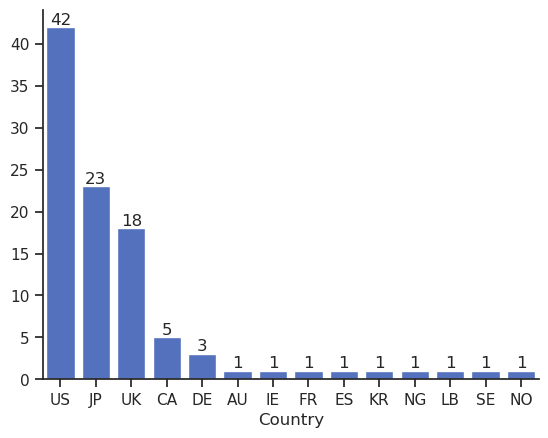

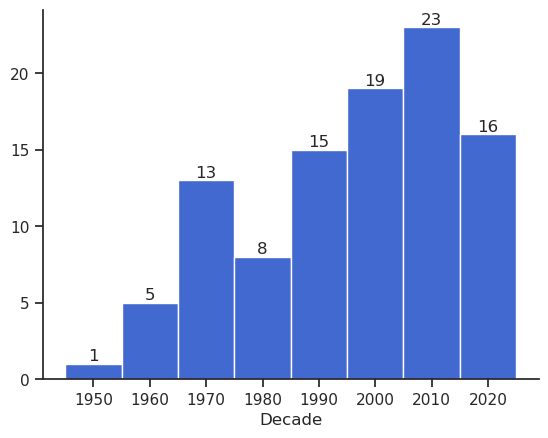

Text(0.5, 0, 'log10(Views)')

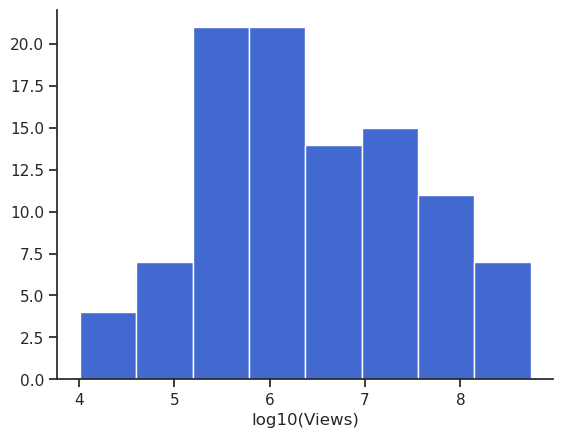

In [116]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("ticks")

obs = [
   "#4269D0FF", "#F0BD3CFF", "#FF5D45FF", "#6CC5B0FF", "#3CA951FF", "#FF8AB7FF",
   "#A463F2FF", "#97BBF5FF", "#9C6B4EFF", "#9498A0FF", "#1B1B1BFF"
]

INPUT_CSV = "data/songs.csv"
df = pd.read_csv(INPUT_CSV)
df = df.head(100)
df = df.sort_index(ascending=False)

counts = (
    df.groupby(["Country", "CountryName"])
      .size()
      .reset_index(name="count")
).sort_values("count", ascending=False).rename(columns={"count": "Count"})

b = sns.barplot(data=counts, x="Country", y="Count", color=obs[0], alpha=1)
sns.despine()
for container in b.containers:
    b.bar_label(container)
plt.ylabel("")
plt.show()

# Decade histogram
df["Decade"] = df["Year"].astype(str).str.slice(0,-3) + ["0"]
h = sns.histplot(data=df[df["Decade"]!="0"].sort_values(by="Decade"), x="Decade", color=obs[0], alpha=1)
h.bar_label(h.containers[0])
sns.despine()
plt.ylabel("")
plt.show()

# Views histogram
sns.histplot(np.log10(df["Views"]), color=obs[0], alpha=1)
sns.despine()
plt.ylabel("")
plt.xlabel("log10(Views)")

### Plotly

In [166]:
import numpy as np

import plotly.express as px
import plotly.io as pio

pio.templates["my_default"] = pio.templates["simple_white"]
pio.templates["my_default"].layout.update(
    font=dict(size=15),
    xaxis=dict(tickfont=dict(size=16)),
    yaxis=dict(tickfont=dict(size=16)),
    margin=dict(l=60, r=30, t=50, b=60),
    width=700,
    height=500,
)
pio.templates["my_default"].layout.colorway = [obs[0][:7]]

s = df["Duration"].astype(str)
s = s.str.replace(".00", "")
s = s.where(s.str.count(":") != 1, "00:" + s)
s.tail(top_n)
df["Duration"] = pd.to_timedelta(s.tail(top_n),  errors="coerce")
df["ViewsFormatted"] = df["Views"].apply(number_formatter)
df["DurationFormatted"] = df["Duration"].astype(str).str.replace("0 days 00:", "")
df["DurationSeconds"] = df["Duration"].dt.total_seconds()

fig = px.scatter(
    df,
    x="DurationSeconds",
    y=np.log10(df["Views"]),
    custom_data=["Title", "ViewsFormatted", "DurationFormatted"],
    template="my_default"
)

fig.update_traces(
    marker_size=10,
    hovertemplate=(
        "<b>%{customdata[0]}</b><br>"
        "Views: %{customdata[1]}<br>"
        "Duration: %{customdata[2]}"
        "<extra></extra>"
    ),
)


fig.update_xaxes(
    showline=True,
    linecolor="black",
    ticks="outside",
    mirror=False,
    fixedrange=True,
    title="Duration (s)"
)

fig.update_yaxes(
    showline=True,
    linecolor="black",
    ticks="outside",
    mirror=False,
    title="log10(Views)",
    fixedrange=True,
)

fig.update_layout(
    dragmode=False,
    modebar_remove=["zoom", "pan", "select", "lasso"]
)

fig.show()

In [167]:
fig = px.bar(
    counts,
    x="Country",
    y="Count",
    hover_data=["CountryName"],
    text="Count",
    template="my_default",
)

fig.update_traces(textposition="outside")

fig.update_layout(
    template="simple_white",
    yaxis_title=None
)

fig.update_xaxes(
    showline=True,
    linecolor="black",
    ticks="outside",
    mirror=False,
    fixedrange=True
)

fig.update_yaxes(
    showline=True,
    linecolor="black",
    ticks="outside",
    mirror=False,
    fixedrange=True
)
fig.show()

In [180]:
df["Decade"] = df["Year"].astype(str).str.slice(0,-3) + ["0"]
df[df["Decade"]!="0"].sort_values(by="Decade")

df["Decade"].value_counts()

Decade
0       35
2010    23
2000    19
2020    16
1990    15
1970    13
1980     8
1960     5
1950     1
Name: count, dtype: int64

In [185]:
dd = df[df["Decade"] != "0"].sort_values(by="Decade")
dd_counts = dd["Decade"].value_counts().sort_index()  # sort index if you want chronological order

fig = px.bar(
    x=dd_counts.index,
    y=dd_counts.values,
    template="my_default",
    text=dd_counts.values
)

fig.update_traces(textposition="outside")
fig.update_layout(
    yaxis_title=None
)
fig.update_xaxes(
    showline=True,
    linecolor="black",
    ticks="outside",
    mirror=False,
    fixedrange=True
)

fig.update_yaxes(
    showline=True,
    linecolor="black",
    ticks="outside",
    mirror=False,
    fixedrange=True
)
fig.show()

In [62]:
import subprocess
import json

retrieve_views = False

if retrieve_views:

    if "Views" not in df.columns:
        df["Views"] = None

    for i in df.index:
        url = df.loc[i, "URL"]
        if pd.isna(url) or pd.notna(df.loc[i, "Views"]):
            continue
        url = str(url)
        print(df.loc[i,"Title"])

        result = subprocess.run(
            ["yt-dlp", "--dump-json", url],
            capture_output=True,
            text=True
        )
        
        try:
            data = json.loads(result.stdout)
        except json.JSONDecodeError:
            print(f">> Failed to retrieve data for {df.loc[i,'Title']}")
            continue
        
        df.loc[i, "Views"] = data.get("view_count")
        if pd.isna(df.loc[i, "Duration"]):
            seconds = data.get("duration")  # seconds
            duration = f"{seconds//60}:{seconds%60}"
            df.loc[i, "Duration"] = duration

Police State Is Nervous
>> Failed to retrieve data for Police State Is Nervous
Together forever, my lovely video game cartridges
Sextape
Borderlands
Come On Up to the House
Al Bosta
8films/tobira
Where the Wind Blows
Cinema Paradiso
Leben einzeln und frei
Run to the Hills
Domination 2
A Hill of the Moon
Ye Entrancemperium 
Sir Duke
Owaranai Uta
Andromeda
Angel of Death
>> Failed to retrieve data for Angel of Death
What's Going On 
Shounen Shoujo
DO YOU DOUBT ME TRAITOR
Rock’n’Roll, Morning Light Falls on You
Blackwater Park
Cámara lenta
White Ceiling
Aerials
Goodbye
Red Rock Riviera
Painkiller
Delusionalism
Questions in a World of Blue
Beautiful World
Run Away With Me
Endsong
This Is Is This?
Kimi no shiranai monogatari
Guilty by Ignorance
Helena
Duk Koo Kim
Willy
$0.00
Glory Box
Weird Fishes/Arpeggi
A Flood of Light
Zombie
Venice Bitch
City Ruins (Rays of Light)
Dream Fighter
Nazi Punks Fuck Off
N.Y. State of Mind
Killing in the Name
Twilight
Le Toit Du Monde
Heaven or Las Vegas 
Blue

In [74]:
import numpy as np

#df.sort_index().to_csv(INPUT_CSV, index=False)

# Views histogram
fig = px.histogram(np.log10(df["Views"]))
fig.update_layout(yaxis_title=None,xaxis_title="log10(YouTube Views)", showlegend=False)
fig.show()

In [ ]:
# df["Duration_sec"] = (
#     pd.to_timedelta("00:" + df["Duration"])
#       .dt.total_seconds()
# )
# df["Duration_min"] = df["Duration_sec"] / 60
# fig = px.histogram(df, x="Duration_min")
# fig.update_layout(yaxis_title=None,xaxis_title="Duration")
# fig.update_xaxes(tickformat="%M:%S")
# fig.show()
#df.drop(["Duation_sec","Duration_min"], axis=1, inplace=True)